# heading

In [1]:
import os
print(os.getcwd())

D:\MSc_2nd_year\JUPYTER\rdk 01


# subsituents selection 

Substituent 'Nitrate' parsed successfully with SMILES: O=[N+]([O-])O
Substituent 'Amine (NH2)' parsed successfully with SMILES: [NH2]
Substituent 'Nitrate Ester' parsed successfully with SMILES: C(O[N+](=O)[O-])
Substituent 'NHNO2 (Nitramide)' parsed successfully with SMILES: N[N+](=O)[O-]
Substituent 'Cyanide' parsed successfully with SMILES: C#N
Substituent 'Hydroxyl (OH)' parsed successfully with SMILES: O
Image successfully saved as 'substituents_grid.png'


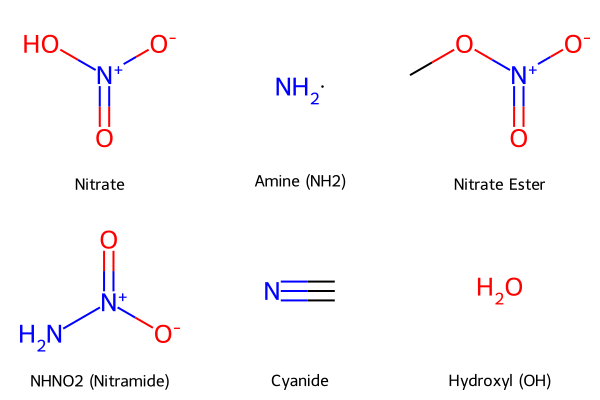

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image
from io import BytesIO

# Substituents with SMILES strings
substituents = {
    "Nitrate": "O=[N+]([O-])O",
    "Amine (NH2)": "[NH2]",
    "Nitrate Ester": "C(O[N+](=O)[O-])",
    "NHNO2 (Nitramide)": "N[N+](=O)[O-]",
    "Cyanide": "C#N",
    "Hydroxyl (OH)": "O"
}

# List to store parsed molecules
parsed_molecules = []

# Parse each substituent
for name, smiles in substituents.items():
    try:
        molecule = Chem.MolFromSmiles(smiles)
        if molecule:
            print(f"Substituent '{name}' parsed successfully with SMILES: {smiles}")
            parsed_molecules.append(molecule)
        else:
            print(f"Failed to parse SMILES for '{name}': {smiles}")
    except Exception as e:
        print(f"Error parsing SMILES for '{name}': {e}")

# Generate the grid image
if parsed_molecules:
    try:
        # Generate the RDKit image
        img = Draw.MolsToGridImage(parsed_molecules, legends=list(substituents.keys()), molsPerRow=3)

        # Convert RDKit's image to a PIL Image for saving
        pil_img = Image.open(BytesIO(img.data))  # Convert RDKit image data to PIL format

        # Save the image as PNG
        output_file = "substituents_grid.png"
        pil_img.save(output_file)
        print(f"Image successfully saved as '{output_file}'")

        # Display the image inline (optional for Jupyter)
        try:
            from IPython.display import Image as IPImage, display
            display(IPImage(filename=output_file))
        except ImportError:
            print(f"Cannot display image inline. Check the saved file '{output_file}' instead.")

    except Exception as e:
        print(f"Error saving image: {e}")
else:
    print("No valid molecules were parsed.")


# Random 35000 molecules generation

In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem
import random
import csv

# Base cubane structure in SMILES
cubane_smiles = "C12C3C4C1C1C2C3C41"

# List of substituents with their SMILES
substituents = {
    "Nitrate": "O=[N+]([O-])O",
    "Amine (NH2)": "[NH2]",
    "Nitrate Ester": "C(O[N+](=O)[O-])",
    "NHNO2 (Nitramide)": "N[N+](=O)[O-]",
    "Cyanide": "C#N",
    "Hydroxyl (OH)": "O"
}

# Function to attach substituents to cubane structure
def attach_substituents(cubane_smiles, substituents, num_derivatives=10):
    base_mol = Chem.MolFromSmiles(cubane_smiles)
    if not base_mol:
        raise ValueError("Invalid base structure SMILES")

    generated_smiles = []

    # Iterate over the desired number of derivatives
    for _ in range(num_derivatives):
        mol = Chem.RWMol(base_mol)  # Create a mutable molecule

        # Randomly select substituents and positions
        num_substituents = random.randint(1, 6)  # Number of substituents to attach (1 to 6)
        selected_positions = random.sample(range(mol.GetNumAtoms()), num_substituents)
        selected_substituents = random.choices(list(substituents.values()), k=num_substituents)

        try:
            for pos, sub_smiles in zip(selected_positions, selected_substituents):
                sub_mol = Chem.MolFromSmiles(sub_smiles)
                if not sub_mol:
                    continue

                # Create a dummy atom to serve as the attachment point
                dummy_idx = mol.AddAtom(Chem.Atom('*'))  # Add a dummy atom
                mol.AddBond(pos, dummy_idx, Chem.BondType.SINGLE)  # Bond dummy to cubane

                # Attach the substituent
                combined = Chem.CombineMols(mol, sub_mol)
                editable_combined = Chem.RWMol(combined)

                # Replace the dummy atom with the substituent
                editable_combined.ReplaceAtom(dummy_idx, sub_mol.GetAtomWithIdx(0))
                mol = editable_combined

            # Generate the final molecule and SMILES
            final_mol = Chem.Mol(mol)
            AllChem.SanitizeMol(final_mol)  # Ensure molecule is valid
            modified_smiles = Chem.MolToSmiles(final_mol)
            generated_smiles.append(modified_smiles)

        except Exception as e:
            print(f"Error generating derivative: {e}")

    return generated_smiles

# Generate random derivatives
num_derivatives = 35000  # Adjust as needed
derivatives = attach_substituents(cubane_smiles, substituents, num_derivatives)

# Save the generated SMILES to a CSV file
output_file = "cubane_derivatives.csv"
with open(output_file, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["SMILES"])
    for smi in derivatives:
        writer.writerow([smi])

print(f"Generated {len(derivatives)} derivatives saved to {output_file}.")


Generated 35000 derivatives saved to cubane_derivatives.csv.


# Remove duplicates

In [4]:
# Remove duplicates from the generated SMILES
unique_derivatives = list(set(derivatives))

# Save the unique SMILES to a CSV file
output_file = "unique_cubane_derivatives.csv"
with open(output_file, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["SMILES"])
    for smi in unique_derivatives:
        writer.writerow([smi])

print(f"Generated {len(unique_derivatives)} unique derivatives saved to {output_file}.")


Generated 10504 unique derivatives saved to unique_cubane_derivatives.csv.


# counting number of distinct group

In [6]:
import pandas as pd
from rdkit import Chem

# Substituent definitions as SMARTS patterns
substituents = {
    "Nitrate": "O=[N+]([O-])O",
    "Amine (NH2)": "[NH2]",
    "Nitrate Ester": "C(O[N+](=O)[O-])",
    "NHNO2 (Nitramide)": "N[N+](=O)[O-]",
    "Cyanide": "C#N",
    "Hydroxyl (OH)": "O",
}

# Function to calculate the number of distinct substituents in a SMILES string
def count_distinct_substituents(smiles, substituents):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:  # Handle invalid SMILES
        return 0
    substituent_matches = set()
    for name, smarts in substituents.items():
        sub_mol = Chem.MolFromSmarts(smarts)
        if sub_mol and mol.HasSubstructMatch(sub_mol):
            substituent_matches.add(name)
    return len(substituent_matches)

# Load the dataset
file_path = "unique_cubane_derivatives.csv"  # Update with your actual file name
df = pd.read_csv(file_path)

# Ensure the 'SMILES' column exists
if 'SMILES' not in df.columns:
    raise ValueError("The dataset must include a 'SMILES' column.")

# Add the NumDistinctSubstituents column
df['NumDistinctSubstituents'] = df['SMILES'].apply(lambda x: count_distinct_substituents(x, substituents))

# Save the updated dataset
output_file = "filtered.csv"
df.to_csv(output_file, index=False)

print(f"Updated dataset saved to '{output_file}' with the new column 'NumDistinctSubstituents'.")


Updated dataset saved to 'filtered.csv' with the new column 'NumDistinctSubstituents'.


# calculation of basis of oxygen balance and filteration

In [7]:
import pandas as pd
from rdkit import Chem

# Function to calculate Oxygen Balance (OB) using the updated formula
def calculate_oxygen_balance(mol):
    # Count atoms
    carbon = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == 'C')  # Count carbon atoms
    hydrogen = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == 'H')  # Count hydrogen atoms
    nitrogen = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == 'N')  # Count nitrogen atoms
    oxygen = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == 'O')  # Count oxygen atoms
    
    # Apply the updated Oxygen Balance formula
    numerator = oxygen - (2 * carbon + hydrogen / 2)
    denominator = carbon + hydrogen + 14 * nitrogen + 16 * oxygen
    OB = (numerator / denominator) * 100
    
    return OB

# Function to filter molecules based on Oxygen Balance
def filter_by_oxygen_balance(input_file, output_file, lower_limit=-2.5, upper_limit=2.5):
    # Load CSV with SMILES strings
    df = pd.read_csv(input_file)
    
    filtered_smiles = []
    
    # Iterate through each SMILES string
    for smile in df['SMILES']:
        mol = Chem.MolFromSmiles(smile)
        if mol:
            # Calculate Oxygen Balance for the molecule
            OB = calculate_oxygen_balance(mol)
            
            # Filter based on OB range
            if lower_limit <= OB <= upper_limit:
                filtered_smiles.append(smile)
    
    # Save the filtered SMILES to a new CSV
    filtered_df = pd.DataFrame(filtered_smiles, columns=["SMILES"])
    filtered_df.to_csv(output_file, index=False)

# Example usage with first 10 molecules for testing
input_file = 'unique_cubane_derivatives.csv'  # Replace with your actual CSV file
output_file = 'filtered_cubane_derivativesOB.csv'  # Output file for filtered SMILES

filter_by_oxygen_balance(input_file, output_file)


# filteration of 200 molecules for training

In [10]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd

# Load the filtered dataset
file_path = "filtered_cubane_derivativesOB.csv"  # Update with your actual file name
df = pd.read_csv(file_path)

# Substituent definitions
substituents = {
    "Nitrate": "O=[N+]([O-])O",
    "Amine (NH2)": "[NH2]",
    "Nitrate Ester": "C(O[N+](=O)[O-])",
    "NHNO2 (Nitramide)": "N[N+](=O)[O-]",
    "Cyanide": "C#N",
    "Hydroxyl (OH)": "O",
}

# Function to count distinct substituents in a molecule
def count_distinct_substituents(smiles, substituents):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    substituent_matches = set()
    for name, smarts in substituents.items():
        sub_mol = Chem.MolFromSmarts(smarts)
        if sub_mol is not None and mol.HasSubstructMatch(sub_mol):
            substituent_matches.add(name)
    return len(substituent_matches)

# Add the NumDistinctSubstituents column to the dataframe
df['NumDistinctSubstituents'] = df['SMILES'].apply(lambda x: count_distinct_substituents(x, substituents))

# Initialize the target dataset
target_df = pd.DataFrame(columns=df.columns)

# Define the number of samples required in the target dataset (e.g., 200)
num_samples = 200

# Calculate the proportional sampling based on the original dataset
substituent_proportions = (
    df['NumDistinctSubstituents'].value_counts(normalize=True).to_dict()
)

# Proportional sampling for each substituent count
for num_species, proportion in substituent_proportions.items():
    sample_size = round(proportion * num_samples)
    subset = df[df['NumDistinctSubstituents'] == num_species]
    
    if len(subset) >= sample_size:
        sampled = subset.sample(n=sample_size, random_state=42)
    else:
        sampled = subset  # Include all available if fewer than required
    
    target_df = pd.concat([target_df, sampled])

# Ensure 1-, 2-, 3-, 4-, 5-, and 6-substituent structures are included
for num_species in [1, 2, 3, 4, 5, 6]:
    if not any(target_df['NumDistinctSubstituents'] == num_species):
        missing_df = df[df['NumDistinctSubstituents'] == num_species]
        if not missing_df.empty:
            additional_sample = missing_df.sample(n=1, random_state=42)
            target_df = pd.concat([target_df, additional_sample])

# Final sampling to match exactly the target size (200 molecules)
if len(target_df) > num_samples:
    target_df = target_df.sample(n=num_samples, random_state=42)

# Save the new dataset
output_file = "balanced_cubane_derivatives200samples.csv"
target_df.to_csv(output_file, index=False)

print(f"Balanced dataset saved to '{output_file}' with {len(target_df)} molecules.")


Balanced dataset saved to 'balanced_cubane_derivatives200samples.csv' with 200 molecules.


# Graph Showing

In [11]:
import pandas as pd

# Load the CSV files for total and selected datasets
total_df = pd.read_csv('filtered_cubane_derivativesOB.csv')  # Replace with actual path to 2979 smiles
selected_df = pd.read_csv('balanced_cubane_derivatives200samples.csv')  # Replace with actual path to 200 smiles


In [12]:
# Define substituent SMILES patterns
substituent_patterns = {
    "Nitrate": "O=[N+]([O-])O",
    "Amine (NH2)": "[NH2]",
    "Nitrate Ester": "C(O[N+](=O)[O-])",
    "NHNO2 (Nitramide)": "N[N+](=O)[O-]",
    "Cyanide": "C#N",
    "Hydroxyl (OH)": "O"
}

# Function to count occurrences of substituents in SMILES
def count_substituents(smiles_list, substituent_patterns):
    counts = {sub: 0 for sub in substituent_patterns}
    for smiles in smiles_list:
        for substituent, pattern in substituent_patterns.items():
            if pattern in smiles:
                counts[substituent] += 1
    return counts


In [17]:
# Calculate proportions for total and selected datasets
total_proportions = {sub: (count / len(total_df)) * 100 for sub, count in total_counts.items()}
selected_proportions = {sub: (count / len(selected_df)) * 100 for sub, count in selected_counts.items()}


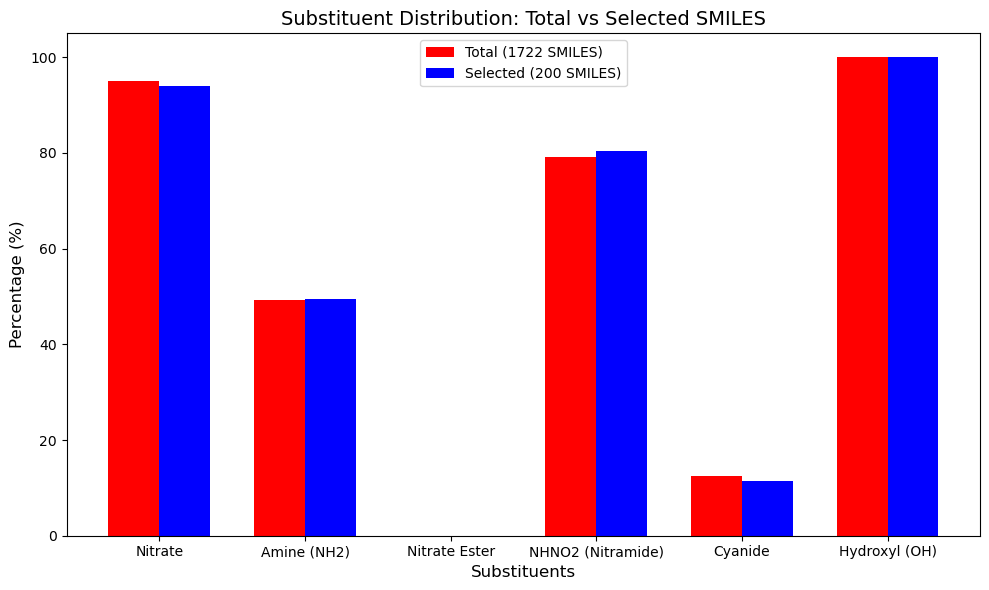

In [19]:
import matplotlib.pyplot as plt

# Prepare data for plotting
substituents = list(substituent_patterns.keys())
total_percentage = [total_proportions[sub] for sub in substituents]
selected_percentage = [selected_proportions[sub] for sub in substituents]

# Plotting the bar chart
bar_width = 0.35
x = range(len(substituents))

plt.figure(figsize=(10, 6))
plt.bar(x, total_percentage, width=bar_width, label='Total (1722 SMILES)', color='red')
plt.bar([p + bar_width for p in x], selected_percentage, width=bar_width, label='Selected (200 SMILES)', color='blue')

# Add labels and title
plt.xlabel('Substituents', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.title('Substituent Distribution: Total vs Selected SMILES', fontsize=14)
plt.xticks([p + bar_width / 2 for p in x], substituents, fontsize=10)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


# calulating number of distinct group with filtered oxygen balance dataset

In [20]:
import pandas as pd
from rdkit import Chem

# Substituent definitions as SMARTS patterns
substituents = {
    "Nitrate": "O=[N+]([O-])O",
    "Amine (NH2)": "[NH2]",
    "Nitrate Ester": "C(O[N+](=O)[O-])",
    "NHNO2 (Nitramide)": "N[N+](=O)[O-]",
    "Cyanide": "C#N",
    "Hydroxyl (OH)": "O",
}

# Function to calculate the number of distinct substituents in a SMILES string
def count_distinct_substituents(smiles, substituents):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:  # Handle invalid SMILES
        return 0
    substituent_matches = set()
    for name, smarts in substituents.items():
        sub_mol = Chem.MolFromSmarts(smarts)
        if sub_mol and mol.HasSubstructMatch(sub_mol):
            substituent_matches.add(name)
    return len(substituent_matches)

# Load the dataset
file_path = "filtered_cubane_derivativesOB.csv"  # Update with your actual file name
df = pd.read_csv(file_path)

# Ensure the 'SMILES' column exists
if 'SMILES' not in df.columns:
    raise ValueError("The dataset must include a 'SMILES' column.")

# Add the NumDistinctSubstituents column
df['NumDistinctSubstituents'] = df['SMILES'].apply(lambda x: count_distinct_substituents(x, substituents))

# Save the updated dataset
output_file = "filteredOB.csv"
df.to_csv(output_file, index=False)

print(f"Updated dataset saved to '{output_file}' with the new column 'NumDistinctSubstituents'.")


Updated dataset saved to 'filteredOB.csv' with the new column 'NumDistinctSubstituents'.


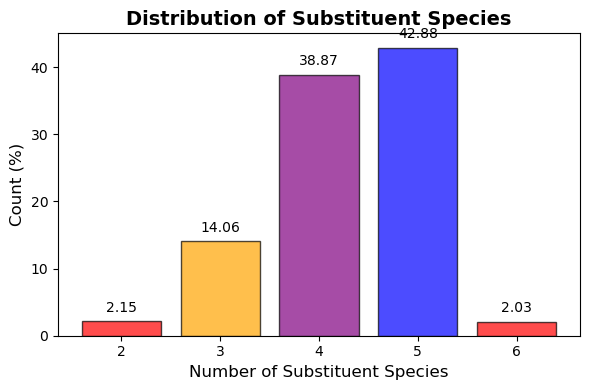

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = "filteredOB.csv"  # Replace with the correct path to your CSV file
data = pd.read_csv(file_path)

# Count the occurrences of each number of distinct groups
group_counts = data["NumDistinctSubstituents"].value_counts().sort_index()

# Calculate percentages
total = group_counts.sum()
percentages = (group_counts / total) * 100

# Plot the bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(
    percentages.index,
    percentages.values,
    color=["red", "orange", "purple", "blue"],
    edgecolor="black",
    alpha=0.7,
)

# Annotate bar heights with percentages
for bar, percentage in zip(bars, percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{percentage:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Add labels, title, and customize ticks
plt.xlabel("Number of Substituent Species", fontsize=12)
plt.ylabel("Count (%)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title("Distribution of Substituent Species", fontsize=14, fontweight="bold")

# Show the plot
plt.tight_layout()
plt.show()


# fixing bonds in 200

In [4]:
import csv
from rdkit import Chem
from rdkit.Chem import AllChem

# Function to attach substituents to the cubane core
def attach_substituents(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if not mol:
            raise ValueError(f"Invalid SMILES: {smiles}")

        # Split the molecule into fragments
        fragments = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
        cubane_core = max(fragments, key=lambda x: x.GetNumAtoms())  # Largest fragment as core

        # Identify substituents (smaller fragments)
        substituents = [frag for frag in fragments if frag != cubane_core]

        # Editable version of the cubane core
        rw_cubane = Chem.RWMol(cubane_core)

        # Find available positions (carbons with degree < 4)
        attachment_points = [
            atom.GetIdx() for atom in rw_cubane.GetAtoms()
            if atom.GetSymbol() == "C" and atom.GetDegree() < 4
        ]

        # Attach each substituent to an available position
        for sub_mol in substituents:
            if not attachment_points:
                break  # Stop if no more positions are available

            # Combine the substituent with the cubane core
            rw_combined = Chem.CombineMols(rw_cubane, sub_mol)
            rw_combined = Chem.RWMol(rw_combined)

            # Attach the substituent to the first available position
            attachment_idx = attachment_points.pop(0)  # Take the first available position
            sub_attachment_idx = rw_combined.GetNumAtoms() - sub_mol.GetNumAtoms()  # First atom of the substituent
            rw_combined.AddBond(attachment_idx, sub_attachment_idx, Chem.BondType.SINGLE)

            # Update the molecule
            rw_cubane = Chem.RWMol(rw_combined)

        # Return the fixed SMILES
        return Chem.MolToSmiles(rw_cubane)
    except Exception as e:
        print(f"Error processing SMILES {smiles}: {e}")
        return None

# Function to process a CSV file with SMILES and save corrected SMILES
def process_smiles_csv(input_file, output_file):
    corrected_data = []

    # Read the input CSV file
    with open(input_file, "r") as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            original_smiles = row["SMILES"]
            corrected_smiles = attach_substituents(original_smiles)
            corrected_data.append({"Original_SMILES": original_smiles, "Corrected_SMILES": corrected_smiles})

    # Write the corrected SMILES to a new CSV file
    with open(output_file, "w", newline="") as csvfile:
        fieldnames = ["Original_SMILES", "Corrected_SMILES"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(corrected_data)

    print(f"Corrected SMILES saved to {output_file}")

# File paths
input_csv = "newbalanced_cubane_derivatives200samples.csv"  # Replace with your input CSV file containing SMILES
output_csv = "corrected_smiles.csv"  # Output file to save corrected SMILES

# Process the SMILES
process_smiles_csv(input_csv, output_csv)


Corrected SMILES saved to corrected_smiles.csv
